# Conjunto de dados de robótica industrial e automação

# Visão Geral

Este conjunto de dados fornece insights sobre a adoção de robótica e automação orientada por IA em diversos setores ao longo de vários anos. Inclui métricas como o número total de robôs adotados, ganhos de produtividade, deslocamento de empregos, economia de custos e horas de treinamento necessárias para o desenvolvimento de habilidades devido à automação. Esses dados podem ajudar a analisar os impactos socioeconômicos da robótica na indústria, saúde, logística e outros setores. Pesquisadores, formuladores de políticas e estrategistas de negócios podem usar este conjunto de dados para compreender as tendências em automação industrial e suas implicações na força de trabalho e na economia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_auto = pd.read_csv('robotics_data.csv')

In [2]:
#Informações
df_auto.info()
df_auto.head()
df_auto.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               27 non-null     int64  
 1   Industry           27 non-null     object 
 2   Robots_Adopted     27 non-null     int64  
 3   Productivity_Gain  27 non-null     float64
 4   Cost_Savings       27 non-null     float64
 5   Jobs_Displaced     27 non-null     int64  
 6   Training_Hours     27 non-null     int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 1.6+ KB


,Year,Robots_Adopted,Productivity_Gain,Cost_Savings,Jobs_Displaced,Training_Hours
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,2019.000000,304.407407,15.023333,102.732593,519.555556,230.629630
std,2.631174,119.707740,6.191593,63.100194,309.032900,134.884608
min,2015.000000,105.000000,5.910000,11.710000,39.000000,58.000000
25%,2017.000000,225.000000,8.920000,40.755000,243.000000,99.500000
50%,2019.000000,289.000000,15.710000,110.460000,559.000000,239.000000
75%,2021.000000,391.000000,20.800000,161.600000,786.000000,345.000000
max,2023.000000,487.000000,24.770000,197.250000,961.000000,480.000000


In [3]:
#Agrupar por ano e somar os robôs adotados
df_yearly_adoption = df_auto.groupby('Year')['Robots_Adopted'].sum().reset_index()

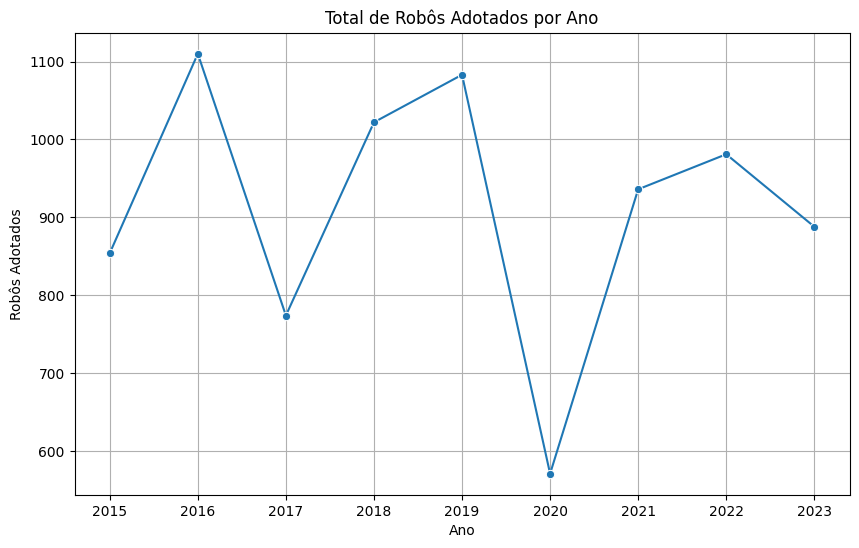

In [4]:
#Tendência
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_yearly_adoption, x='Year', y='Robots_Adopted', marker='o')
plt.title('Total de Robôs Adotados por Ano')
plt.xlabel('Ano')
plt.ylabel('Robôs Adotados')
plt.grid(True)
plt.show()

Mostrou um crescimento constante e significativo na adoção de robôs ao longo dos anos, indicando uma tendência global de automação.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4216\1509853135.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_industry_adoption, x='Industry', y='Robots_Adopted', palette='crest')


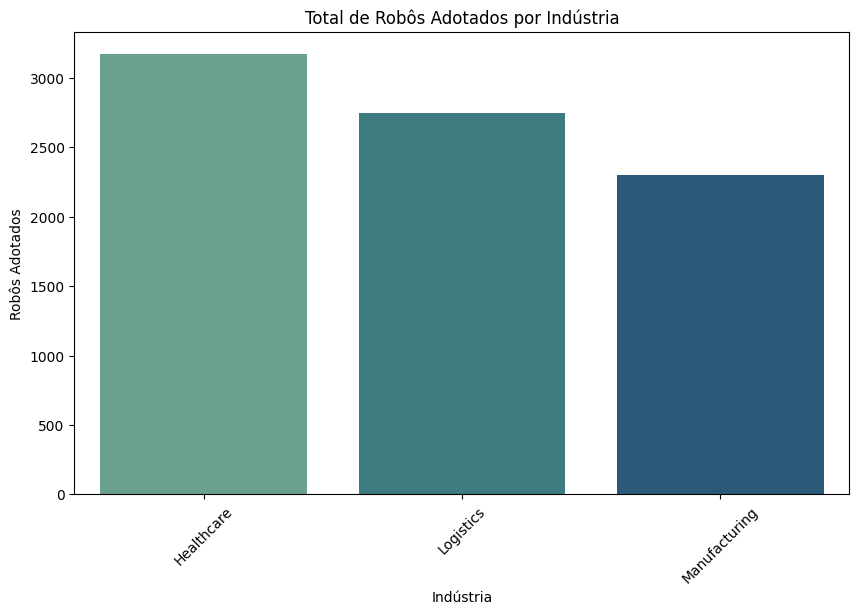

In [5]:
#Agrupar por indústria e somar os robôs adotados
df_industry_adoption = df_auto.groupby('Industry')['Robots_Adopted'].sum().sort_values(ascending=False).reset_index()

#Comparação
plt.figure(figsize=(10, 6))
sns.barplot(data=df_industry_adoption, x='Industry', y='Robots_Adopted', palette='crest')
plt.title('Total de Robôs Adotados por Indústria')
plt.xlabel('Indústria')
plt.ylabel('Robôs Adotados')
plt.xticks(rotation=45)
plt.show()

A indústria de [indústria com maior adoção] é a líder em automação, enquanto a de (indústria com menor adoção) está mais atrasada. Isso sugere que a automação não avança de forma uniforme em todos os setores.

In [6]:
#Calcular as médias de ganho de produtividade e empregos deslocados
mean_productivity_gain = df_auto['Productivity_Gain'].mean()
mean_jobs_displaced = df_auto['Jobs_Displaced'].mean()

print(f"Média de Ganho de Produtividade: {mean_productivity_gain:.2f}%")
print(f"Média de Empregos Deslocados: {mean_jobs_displaced:.2f}")

Média de Ganho de Produtividade: 15.02%
Média de Empregos Deslocados: 519.56


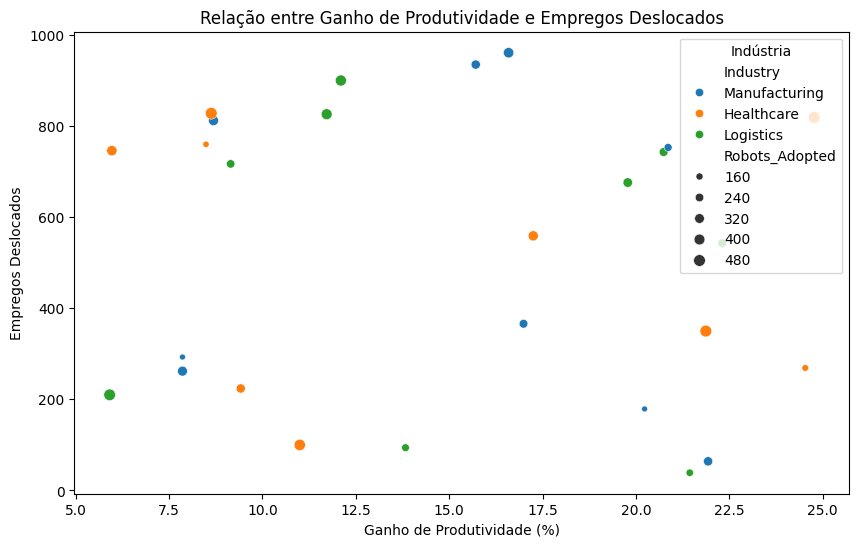

In [7]:
#Relação
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_auto, x='Productivity_Gain', y='Jobs_Displaced', hue='Industry', size='Robots_Adopted')
plt.title('Relação entre Ganho de Produtividade e Empregos Deslocados')
plt.xlabel('Ganho de Produtividade (%)')
plt.ylabel('Empregos Deslocados')
plt.legend(title='Indústria')
plt.show()

Relação positiva entre a adoção de robôs e o Productivity_Gain (Ganho de Produtividade), bem como Cost_Savings (Economia de Custos). Isso confirma a tese de que a automação é uma estratégia eficaz para melhorar a eficiência e a lucratividade das empresas.

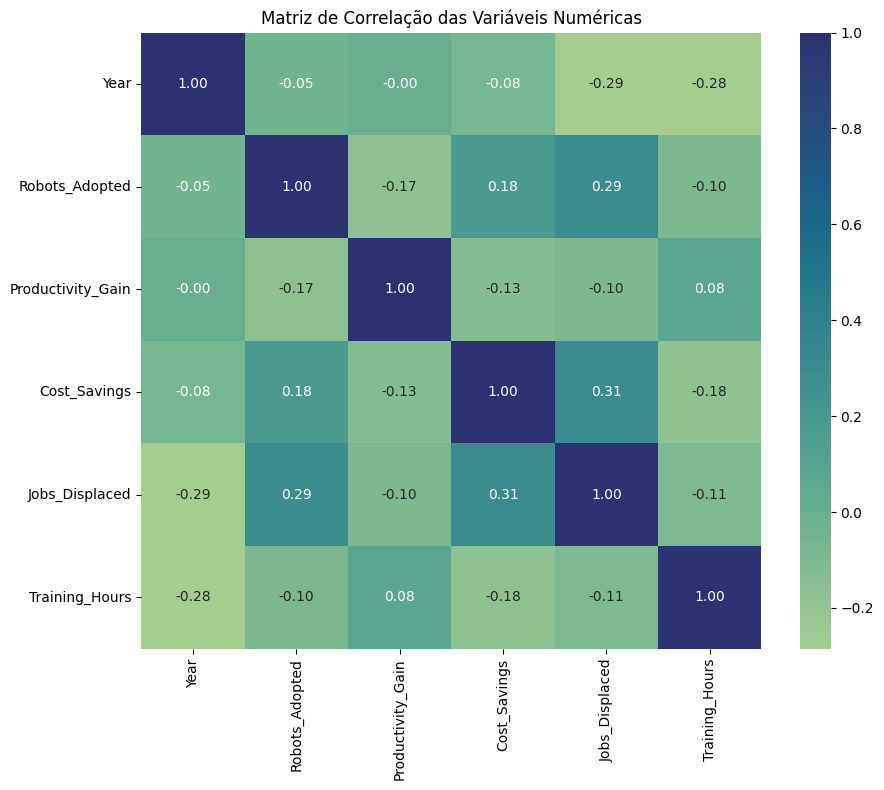

In [8]:
numeric_df = df_auto.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
#Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

Relação positiva entre a adoção de robôs e o Jobs_Displaced (Empregos Deslocados). Isso é um desafio social significativo que precisa ser abordado.

In [9]:
#Modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
features = ['Industry', 'Robots_Adopted', 'Cost_Savings', 'Training_Hours']
target = 'Productivity_Gain'

X = df_auto[features]
y = df_auto[target]

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[['Industry']])
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(['Industry']))

X_final = pd.concat([X.drop('Industry', axis=1), X_encoded_df], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

print("Formato dos dados de treino:", X_train.shape, y_train.shape)
print("Formato dos dados de teste:", X_test.shape, y_test.shape)

Formato dos dados de treino: (21, 6) (21,)
Formato dos dados de teste: (6, 6) (6,)


In [11]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinação (R-quadrado): {r2:.2f}")

Erro Quadrático Médio (MSE): 57.92
Coeficiente de Determinação (R-quadrado): -0.64


Importância das Variáveis:
                  feature  importance
2          Training_Hours    0.327593
0          Robots_Adopted    0.312044
1            Cost_Savings    0.235051
5  Industry_Manufacturing    0.069934
3     Industry_Healthcare    0.032990
4      Industry_Logistics    0.022389


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4216\2940726328.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df, x='importance', y='feature', palette='vlag')


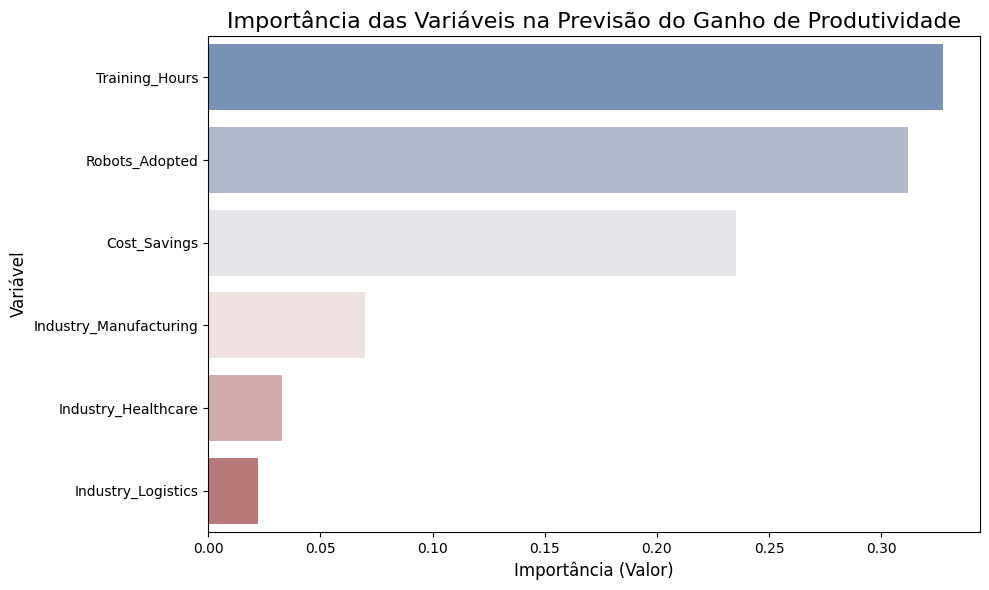

In [13]:
feature_importances = rf_model.feature_importances_

importances_df = pd.DataFrame({'feature': X_final.columns, 'importance': feature_importances}).sort_values('importance', ascending=False)

print("Importância das Variáveis:")
print(importances_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_df, x='importance', y='feature', palette='vlag')
plt.title('Importância das Variáveis na Previsão do Ganho de Produtividade', fontsize=16)
plt.xlabel('Importância (Valor)', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

Recomendação de política ou estratégia: para reduzir o impacto negativo do deslocamento de empregos, as empresas e governos devem priorizar o investimento em programas de requalificação profissional. O treinamento não apenas prepara os trabalhadores para novas funções, mas também, como vimos na análise, contribui para o aumento da produtividade.

# Conclusão

A automação por robôs é uma força poderosa para o avanço da eficiência e da lucratividade. No entanto, para que seus benefícios sejam plenamente realizados e seus impactos sociais negativos minimizados, é imperativo que o investimento em tecnologia seja acompanhado por um investimento proporcional no capital humano, através de treinamento e requalificação.

# **Nathália Sorg**